In [9]:
import pandas as pd
G_train = pd.read_csv("GoEmotions/Processed/GoEmotions_train.csv")
G_test = pd.read_csv("GoEmotions/Processed/GoEmotions_test.csv")

S_train = pd.read_csv("SemEvalDataset/processed/train.csv")
S_test = pd.read_csv("SemEvalDataset/processed/test.csv")

T_train = pd.read_csv("TwitterEmotions/training.csv")
T_test = pd.read_csv("TwitterEmotions/test.csv")

In [10]:
G_train = G_train.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})
G_test = G_test.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})

In [11]:
emotions = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

def parse_labels(label_str):
    return [int(x) for x in str(label_str).split(",")]

def make_multilabel_columns(df):
    df = df.copy()

    # Convert "13,18" into [13, 18]
    df["label_list"] = df["label_id"].apply(parse_labels)

    # Add readable labels: [13,18] -> ["excitement", "love"]
    df["label_names"] = df["label_list"].apply(
        lambda ids: [emotions[i] for i in ids]
    )

    # Create one binary column per emotion
    for i, emotion in enumerate(emotions):
        df[emotion] = df["label_list"].apply(lambda labels: 1 if i in labels else 0)

    return df

G_train = make_multilabel_columns(G_train)
G_test = make_multilabel_columns(G_test)

# print(goemotions_train[["label_id", "label_list", "label_names"]].head())

emotion_cols = emotions
print(G_train.columns)
print(G_test.columns)

Index(['text', 'label_id', 'example_id', 'label_list', 'label_names',
       'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')
Index(['text', 'label_id', 'example_id', 'label_list', 'label_names',
       'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')


Here is a method that can be used for cleaning text and finding the most common words.

In [ ]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "im", "ive", "dont", "didnt", "doesnt", "cant", "couldnt",
    "wouldnt", "isnt", "arent", "wasnt", "werent",
    "feel", "feeling", "felt", "like", "just", "really",
    "know", "time", "people", "day", "going", "want"
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()

    words = [
        word for word in words
        if word not in custom_stopwords and len(word) > 2
    ]

    return words

# Go Emotions Analysis

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Basic Text Length Features
# -----------------------------

G_train["word_count"] = G_train["text"].apply(
    lambda text: len(str(text).split())
)

G_train["clean_word_count"] = G_train["text"].apply(
    lambda text: len(clean_text(text))
)

G_train["char_count"] = G_train["text"].apply(
    lambda text: len(str(text))
)

print("Average raw words per comment:", G_train["word_count"].mean())
print("Median raw words per comment:", G_train["word_count"].median())
print("Average cleaned words per comment:", G_train["clean_word_count"].mean())
print("Median cleaned words per comment:", G_train["clean_word_count"].median())
print("Average characters per comment:", G_train["char_count"].mean())

Average raw words per comment: 12.840175074867542
Median raw words per comment: 12.0
Average cleaned words per comment: 5.196083851647086
Median cleaned words per comment: 5.0
Average characters per comment: 68.40087537433772


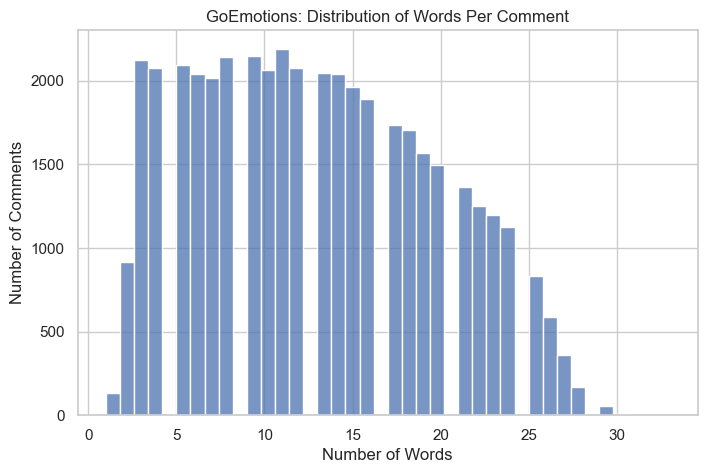

In [114]:
plt.figure(figsize=(8,5))

sns.histplot(
    G_train["word_count"],
    bins=40
)

plt.title("GoEmotions: Distribution of Words Per Comment")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.show()

In [115]:
length_rows = []

for emotion in emotion_cols:
    emotion_comments = G_train[G_train[emotion] == 1]

    length_rows.append({
        "Emotion": emotion,
        "Avg Raw Words": emotion_comments["word_count"].mean(),
        "Median Raw Words": emotion_comments["word_count"].median(),
        "Avg Cleaned Words": emotion_comments["clean_word_count"].mean(),
        "Median Cleaned Words": emotion_comments["clean_word_count"].median(),
        "Avg Characters": emotion_comments["char_count"].mean(),
        "Sample Count": len(emotion_comments)
    })

goemotion_length_table = pd.DataFrame(length_rows)

goemotion_length_table = goemotion_length_table.sort_values(
    "Avg Raw Words",
    ascending=False
)

goemotion_length_table

,Emotion,Avg Raw Words,Median Raw Words,Avg Cleaned Words,Median Cleaned Words,Avg Characters,Sample Count
20,optimism,15.537002,16.0,6.118912,6.0,80.512334,1581
22,realization,15.222523,15.0,5.818919,6.0,80.697297,1110
8,desire,14.622465,14.0,5.399376,5.0,73.263651,641
9,disappointment,14.449173,14.0,5.730496,5.0,77.160757,1269
6,confusion,14.409357,14.0,5.368421,5.0,75.980263,1368
12,embarrassment,14.306931,14.0,5.755776,5.0,77.415842,303
19,nervousness,14.262195,15.0,5.500000,5.0,75.439024,164
5,caring,14.108556,14.0,5.546458,5.0,74.111316,1087
10,disapproval,13.978239,14.0,5.652819,5.0,75.771513,2022
3,annoyance,13.964372,14.0,5.811336,5.0,75.713360,2470


## Label Distribution

num_labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64


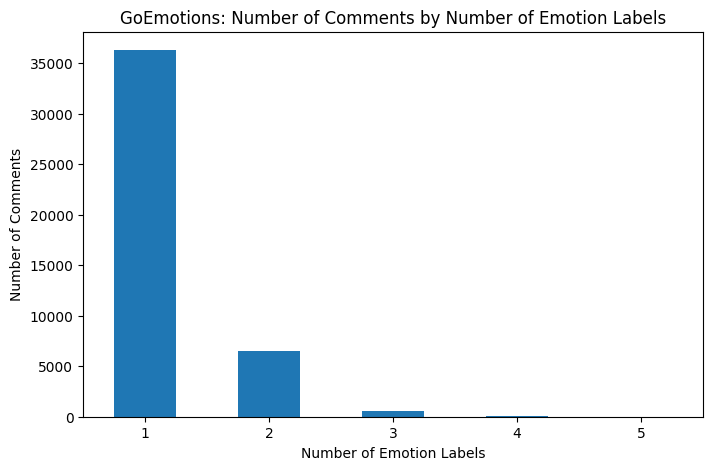

In [43]:
import matplotlib.pyplot as plt

# Count how many labels each comment has
G_train["num_labels"] = G_train[emotion_cols].sum(axis=1)

# Count how many comments have 1 label, 2 labels, 3 labels, etc.
label_count_distribution = (
    G_train["num_labels"]
    .value_counts()
    .sort_index()
)

print(label_count_distribution)

# Plot distribution
label_count_distribution.plot(kind="bar", figsize=(8, 5))

plt.title("GoEmotions: Number of Comments by Number of Emotion Labels")
plt.xlabel("Number of Emotion Labels")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()

## Emotion Statistics

In [12]:
print("Total samples in GoEmotions train:", len(G_train))
print("Total samples in GoEmotions test:", len(G_test))
print("Number of emotion columns:", 28)
labels_per_comment_train = G_train[emotion_cols].sum(axis=1)
labels_per_comment_test = G_test[emotion_cols].sum(axis=1)

print("Average labels per comment in GoEmotions train:",labels_per_comment_train.mean())
print("Average labels per comment in GoEmotions test:",labels_per_comment_test.mean())

multi_label_train = (labels_per_comment_train > 1).sum()
print("Multi-label samples in train data:", multi_label_train)
print("Percentage:", 100 * multi_label_train / len(G_train))

multi_label_test = (labels_per_comment_test > 1).sum()
print("Multi-label samples in train data:", multi_label_test)
print("Percentage:", 100 * multi_label_test / len(G_test))

Total samples in GoEmotions train: 43410
Total samples in GoEmotions test: 5427
Number of emotion columns: 28
Average labels per comment in GoEmotions train: 1.1772172310527529
Average labels per comment in GoEmotions test: 1.1662060070020268
Multi-label samples in train data: 7102
Percentage: 16.360285648468096
Multi-label samples in train data: 837
Percentage: 15.422885572139304


## Emotion Frequency

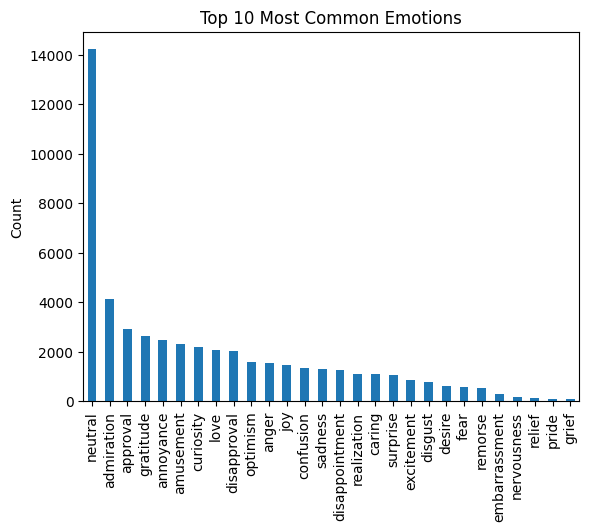

                Count  Percent
neutral         14219    27.82
admiration       4130     8.08
approval         2939     5.75
gratitude        2662     5.21
annoyance        2470     4.83
amusement        2328     4.56
curiosity        2191     4.29
love             2086     4.08
disapproval      2022     3.96
optimism         1581     3.09
anger            1567     3.07
joy              1452     2.84
confusion        1368     2.68
sadness          1326     2.59
disappointment   1269     2.48
realization      1110     2.17
caring           1087     2.13
surprise         1060     2.07
excitement        853     1.67
disgust           793     1.55
desire            641     1.25
fear              596     1.17
remorse           545     1.07
embarrassment     303     0.59
nervousness       164     0.32
relief            153     0.30
pride             111     0.22
grief              77     0.15


In [15]:
import matplotlib.pyplot as plt

emotion_counts = G_train[emotion_cols].sum().sort_values(ascending=False)

emotion_counts.plot(kind="bar")
plt.title("Top 10 Most Common Emotions")
plt.ylabel("Count")
plt.show()

emotion_percentages = (
    emotion_counts / emotion_counts.sum() * 100
).round(2)

summary = pd.DataFrame({
    "Count": emotion_counts,
    "Percent": emotion_percentages
})

print(summary)

## Emotion Co-occurance 

In [30]:
import numpy as np
co_matrix = G_train[emotion_cols].T.dot(G_train[emotion_cols])
co_matrix_plot = co_matrix.copy()

for emotion in emotion_cols:
    co_matrix_plot.loc[emotion, emotion] = 0

co_matrix = co_matrix_plot
print(co_matrix)

                admiration  amusement  anger  annoyance  approval  caring  \
admiration               0         84      5         25       246      31   
amusement               84          0     15         40        57       8   
anger                    5         15      0        269         8       9   
annoyance               25         40    269          0        37      13   
approval               246         57      8         37         0      65   
caring                  31          8      9         13        65       0   
confusion               24         24      8         24        20       1   
curiosity               65         48     11         45        36      15   
desire                  33         10      4         12        18      11   
disappointment          24         10     30        110        23      10   
disapproval             14         20     43        178        19      14   
disgust                 10          9     53         80        13       2   

           Emotion1        Emotion2  Count
14       admiration       gratitude    279
53            anger       annoyance    269
3        admiration        approval    246
147       confusion       curiosity    212
124        approval         neutral    202
17       admiration            love    192
84        annoyance     disapproval    178
222  disappointment         sadness    133
101       annoyance         neutral    132
16       admiration             joy    126
187       curiosity         neutral    118
83        annoyance  disappointment    110
241     disapproval         neutral    109
19       admiration        optimism    106
117        approval        optimism    100
167       confusion         neutral     98
26       admiration         neutral     94
139          caring        optimism     90
42        amusement             joy     90
276      excitement             joy     86


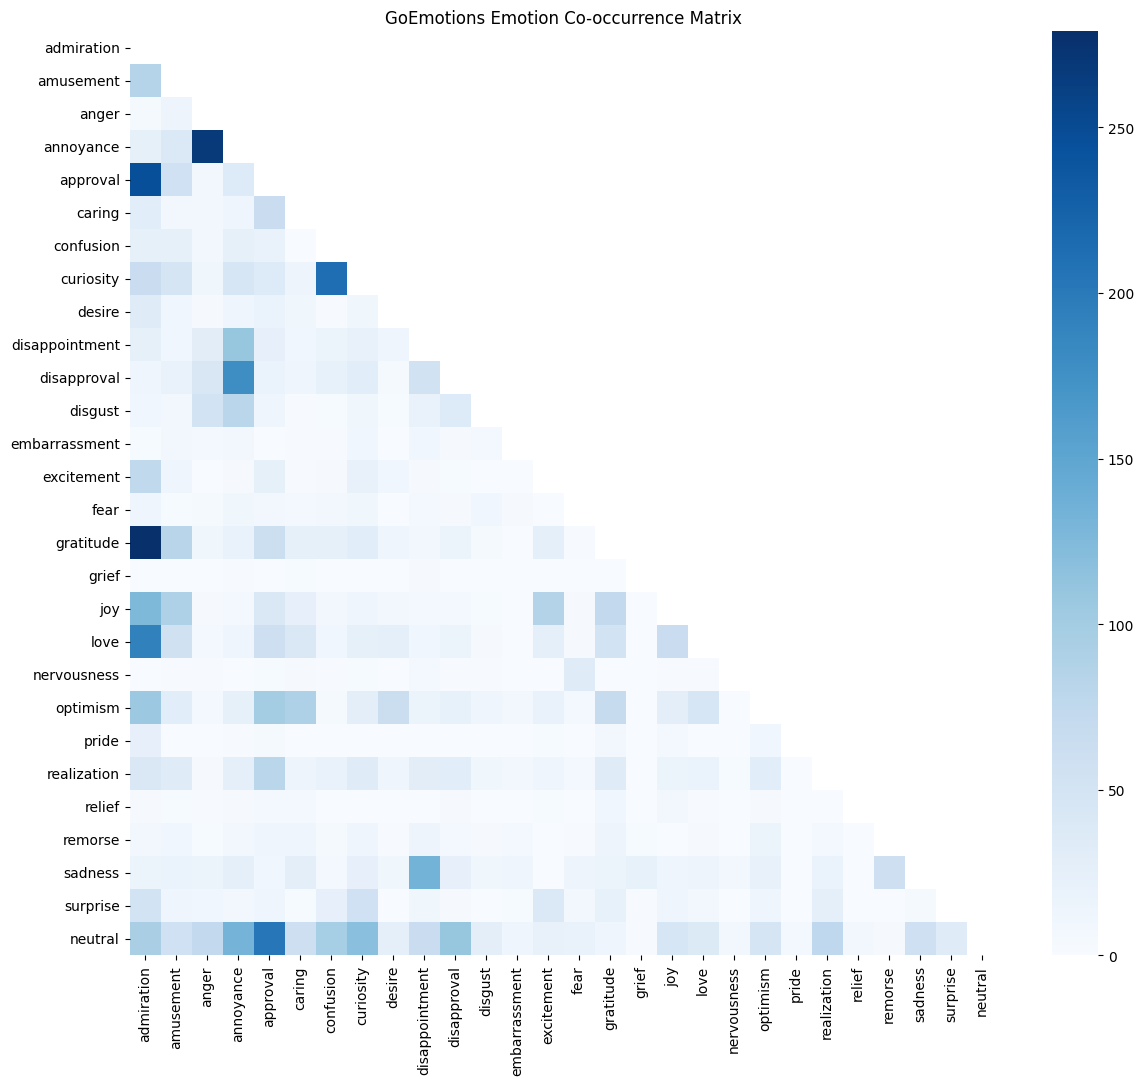

In [42]:
pairs = []

for i in range(len(emotion_cols)):
    for j in range(i+1, len(emotion_cols)):
        pairs.append(
            (
                emotion_cols[i],
                emotion_cols[j],
                co_matrix.iloc[i, j]
            )
        )

pairs_df = pd.DataFrame(
    pairs,
    columns=["Emotion1", "Emotion2", "Count"]
)

pairs_df = pairs_df.sort_values(
    "Count",
    ascending=False
)

print(pairs_df.head(20))

import seaborn as sns
import matplotlib.pyplot as plt

mask = np.triu(np.ones_like(co_matrix, dtype=bool))

plt.figure(figsize=(14,12))

sns.heatmap(
    co_matrix,
    mask=mask,
    cmap="Blues"
)

plt.title("GoEmotions Emotion Co-occurrence Matrix")
plt.show()

## Male vs Female

In [94]:
G_male_comments = G_train[
    G_train["text"].str.contains(
        r"\b(he|him|his)\b",
        case=False,
        regex=True,
        na=False
    )
]

G_female_comments = G_train[
    G_train["text"].str.contains(
        r"\b(she|her|hers)\b",
        case=False,
        regex=True,
        na=False
    )
]

/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/2565989487.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_train["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/2565989487.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_train["text"].str.contains(


In [97]:
G_male_emotions = G_male_comments[emotion_cols].sum().sort_values(ascending=False)

G_female_emotions = G_female_comments[emotion_cols].sum().sort_values(ascending=False)

G_male_pct = (
    G_male_comments[emotion_cols].sum()
    / len(G_male_comments)
    * 100
).sort_values(ascending=False)

G_female_pct = (
    G_female_comments[emotion_cols].sum()
    / len(G_female_comments)
    * 100
).sort_values(ascending=False)

G_comparison = pd.DataFrame({
    "Male %": G_male_pct,
    "Female %": G_female_pct
})

# Difference
Right now kind of hard to tell the difference so we can look more into that

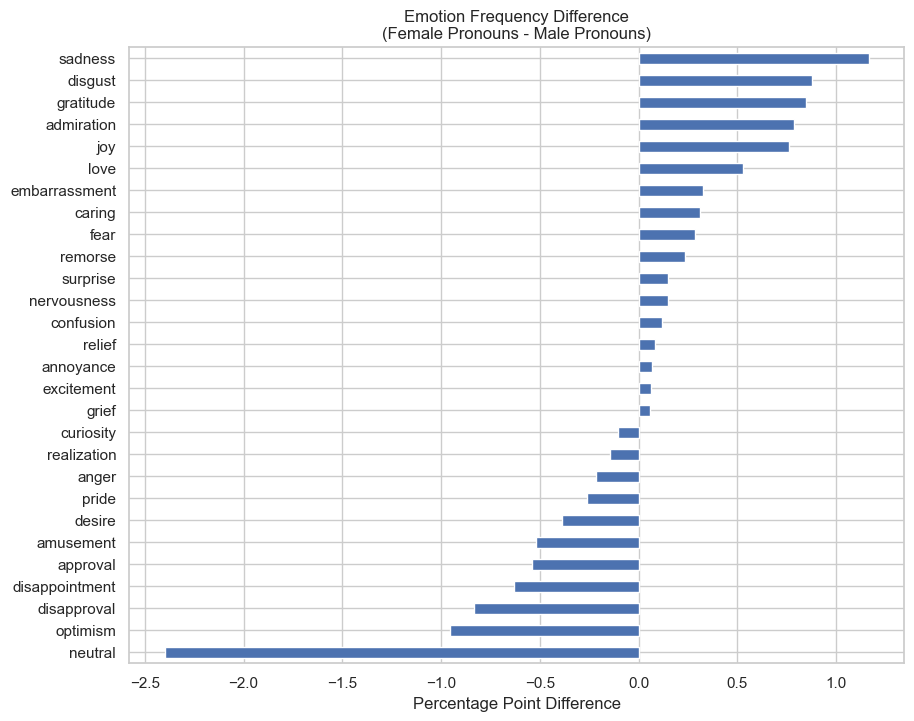

In [99]:
G_comparison["Difference"] = (
    G_comparison["Female %"] - G_comparison["Male %"]
)

G_comparison = G_comparison.sort_values(
    "Difference",
    ascending=False
)

G_comparison["Difference"].sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Emotion Frequency Difference\n(Female Pronouns - Male Pronouns)")
plt.xlabel("Percentage Point Difference")
plt.show()

In [100]:
G_comparison

,Male %,Female %,Difference
sadness,2.932895,4.100228,1.167332
disgust,1.853590,2.733485,0.879895
gratitude,2.252464,3.097950,0.845486
admiration,9.784139,10.569476,0.785337
joy,2.064758,2.824601,0.759843
love,5.349601,5.876993,0.527392
embarrassment,0.539653,0.865604,0.325951
caring,2.651337,2.961276,0.309938
fear,1.173158,1.457859,0.284701
remorse,0.586579,0.820046,0.233466


## Most Common Words Per Emotion

In [79]:
emotion_cols = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

In [81]:
summary_rows = []

for emotion in emotion_cols:

    emotion_texts = G_train.loc[
        G_train[emotion] == 1,
        "text"
    ]

    all_words = []

    for text in emotion_texts:
        all_words.extend(clean_text(text))

    top_words = [
        word
        for word, count in Counter(all_words).most_common(5)
    ]

    summary_rows.append({
        "Emotion": emotion,
        "Most Common Words": top_words
    })

pd.set_option("display.max_colwidth", None)

goemotion_word_table = pd.DataFrame(summary_rows)

goemotion_word_table

,Emotion,Most Common Words
0,admiration,"[good, great, awesome, amazing, love]"
1,amusement,"[lol, haha, funny, fun, lmao]"
2,anger,"[fuck, hate, fucking, don, stupid]"
3,annoyance,"[don, fucking, stupid, fuck, damn]"
4,approval,"[right, good, agree, yes, yeah]"
5,caring,"[don, good, better, help, need]"
6,confusion,"[don, sure, think, confused, did]"
7,curiosity,"[did, curious, does, think, don]"
8,desire,"[wish, need, hope, love, wanted]"
9,disappointment,"[bad, don, didn, game, got]"


# Twitter Emotions Analysis

## Emotion Frequency

In [66]:
emotion_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

T_train["emotion"] = T_train["label"].map(emotion_map)
T_test["emotion"] = T_test["label"].map(emotion_map)

#sns.set_theme(style="whitegrid")

In [67]:
emotion_freq = (
    T_train["emotion"]
    .value_counts()
    .reset_index()
)

emotion_freq.columns = ["Emotion", "Count"]
emotion_freq["Percent"] = (
    emotion_freq["Count"] / len(T_train) * 100
).round(2)

emotion_freq

,Emotion,Count,Percent
0,joy,5362,33.51
1,sadness,4666,29.16
2,anger,2159,13.49
3,fear,1937,12.11
4,love,1304,8.15
5,surprise,572,3.58


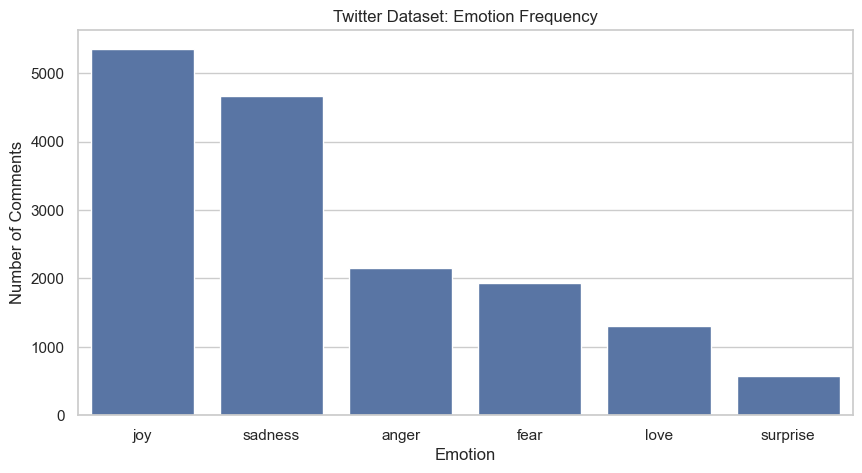

In [68]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=emotion_freq,
    x="Emotion",
    y="Count"
)

plt.title("Twitter Dataset: Emotion Frequency")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")

plt.show()

## Most common words for each emotion

In [75]:
summary_rows = []

for emotion in sorted(T_train["emotion"].unique()):

    emotion_texts = T_train.loc[
        T_train["emotion"] == emotion,
        "text"
    ]

    all_words = []

    for text in emotion_texts:
        all_words.extend(clean_text(text))

    top_words = [
        word
        for word, count in Counter(all_words).most_common(10)
    ]

    summary_rows.append({
        "Emotion": emotion,
        "Most Common Words": top_words
    })
pd.set_option('display.max_colwidth', None)

emotion_word_table = pd.DataFrame(summary_rows)

emotion_word_table

,Emotion,Most Common Words
0,anger,"[little, angry, way, think, things, bit, irritable, cold, don, life]"
1,fear,"[little, bit, strange, think, nervous, terrified, anxious, afraid, scared, unsure]"
2,joy,"[make, think, good, love, little, pretty, life, happy, things, need]"
3,love,"[love, sweet, loving, passionate, caring, life, little, sympathetic, hot, lovely]"
4,sadness,"[little, life, think, bit, things, make, way, pretty, don, love]"
5,surprise,"[amazed, impressed, overwhelmed, weird, surprised, curious, funny, strange, shocked, little]"


## Gender Comparison

In [91]:
T_male_comments = T_train[
    T_train["text"].str.contains(
        r"\b(he|him|his)\b",
        case=False,
        regex=True,
        na=False
    )
]

T_female_comments = T_train[
    T_train["text"].str.contains(
        r"\b(she|her|hers)\b",
        case=False,
        regex=True,
        na=False
    )
]

/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/2335013582.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  T_train["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/2335013582.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  T_train["text"].str.contains(


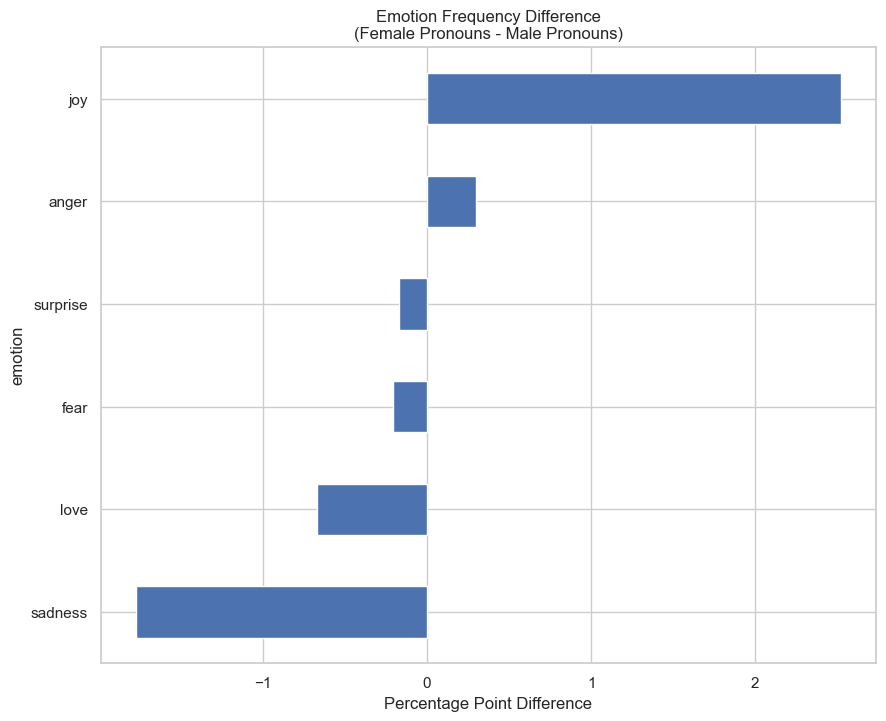

In [ ]:
T_male_pct = (
    T_male_comments["emotion"]
    .value_counts(normalize=True)
    * 100
)

T_female_pct = (
    T_female_comments["emotion"]
    .value_counts(normalize=True)
    * 100
)

T_comparison = pd.DataFrame({
    "Male %": T_male_pct,
    "Female %": T_female_pct
}).fillna(0)

T_comparison["Difference"] = (
    T_comparison["Female %"] - T_comparison["Male %"]
)

T_comparison = T_comparison.sort_values(
    "Difference",
    ascending=False
)

T_comparison["Difference"].sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Emotion Frequency Difference\n(Female Pronouns - Male Pronouns)")
plt.xlabel("Percentage Point Difference")
plt.show()

In [78]:
T_comparison

,Male %,Female %,Difference
emotion,,,
joy,28.542714,31.065089,2.522375
anger,15.678392,15.976331,0.297939
surprise,3.718593,3.550296,-0.168297
fear,11.155779,10.946746,-0.209033
love,12.060302,11.390533,-0.669769
sadness,28.844221,27.071006,-1.773215


# SemEval Analysis

In [103]:
S_emotion_cols = [
    "anger", "anticipation", "disgust", "fear", "joy",
    "love", "optimism", "pessimism", "sadness",
    "surprise", "trust"
]

len(S_train)

6838

In [101]:
S_train["num_labels"] = S_train[S_emotion_cols].sum(axis=1)

label_distribution = (
    S_train["num_labels"]
    .value_counts()
    .sort_index()
)

label_distribution

num_labels
0     204
1     982
2    2773
3    2114
4     658
5      96
6      11
Name: count, dtype: int64

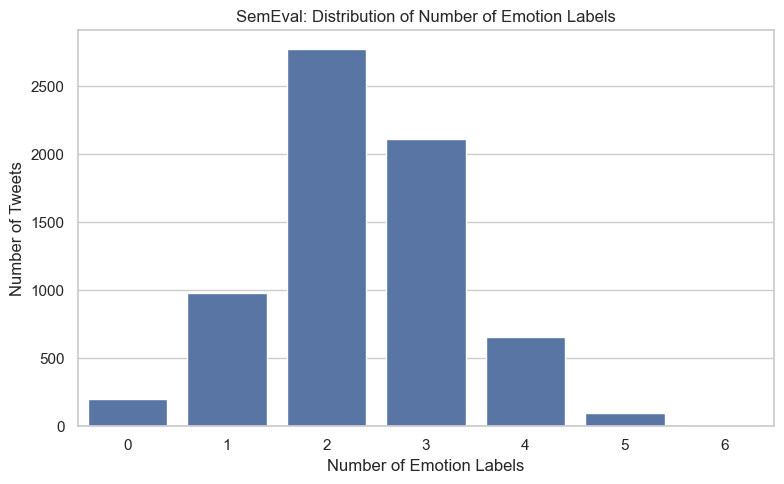

In [102]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=label_distribution.index,
    y=label_distribution.values
)

plt.title("SemEval: Distribution of Number of Emotion Labels")
plt.xlabel("Number of Emotion Labels")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()

In [83]:
S_emotion_freq = S_train[S_emotion_cols].sum().sort_values(ascending=False)

S_emotion_freq_table = pd.DataFrame({
    "Emotion": S_emotion_freq.index,
    "Count": S_emotion_freq.values,
    "Percent": (S_emotion_freq.values / len(S_train) * 100).round(2)
})

S_emotion_freq_table

,Emotion,Count,Percent
0,disgust,2602,38.05
1,anger,2544,37.20
2,joy,2477,36.22
3,sadness,2008,29.37
4,optimism,1984,29.01
5,fear,1242,18.16
6,anticipation,978,14.30
7,pessimism,795,11.63
8,love,700,10.24
9,surprise,361,5.28


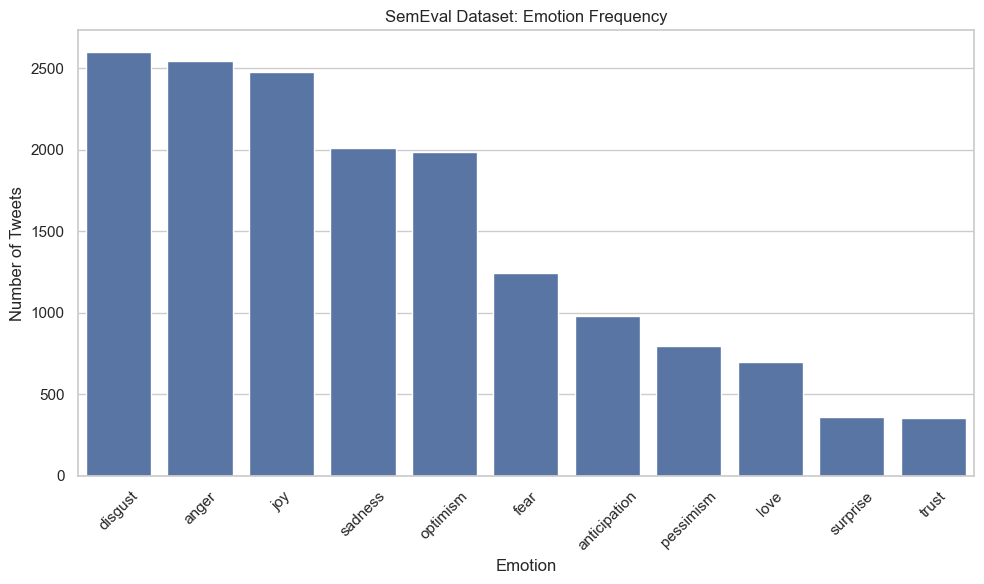

In [84]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=S_emotion_freq_table,
    x="Emotion",
    y="Count"
)

plt.title("SemEval Dataset: Emotion Frequency")
plt.xlabel("Emotion")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [85]:
S_male_mask = S_train["Tweet"].str.contains(
    r"\b(he|him|his)\b",
    case=False,
    regex=True,
    na=False
)

S_female_mask = S_train["Tweet"].str.contains(
    r"\b(she|her|hers)\b",
    case=False,
    regex=True,
    na=False
)

S_male_comments = S_train[S_male_mask & ~S_female_mask]
S_female_comments = S_train[S_female_mask & ~S_male_mask]

print("Male comments:", len(S_male_comments))
print("Female comments:", len(S_female_comments))

Male comments: 493
Female comments: 264


/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/3757476143.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  S_male_mask = S_train["Tweet"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_72228/3757476143.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  S_female_mask = S_train["Tweet"].str.contains(


In [86]:
S_male_pct = (
    S_male_comments[S_emotion_cols].sum()
    / len(S_male_comments)
    * 100
)

S_female_pct = (
    S_female_comments[S_emotion_cols].sum()
    / len(S_female_comments)
    * 100
)

S_comparison = pd.DataFrame({
    "Male %": S_male_pct,
    "Female %": S_female_pct
})

S_comparison["Difference"] = (
    S_comparison["Female %"] - S_comparison["Male %"]
)

S_comparison = S_comparison.sort_values(
    "Difference",
    ascending=False
)

S_comparison

,Male %,Female %,Difference
love,9.736308,17.803030,8.066722
sadness,22.920892,26.136364,3.215471
anticipation,12.373225,14.772727,2.399502
pessimism,9.736308,11.363636,1.627328
surprise,4.868154,6.439394,1.571240
joy,34.685598,35.984848,1.299250
trust,5.070994,6.060606,0.989612
optimism,23.935091,23.863636,-0.071455
fear,16.024341,14.015152,-2.009189
disgust,44.827586,38.257576,-6.570010


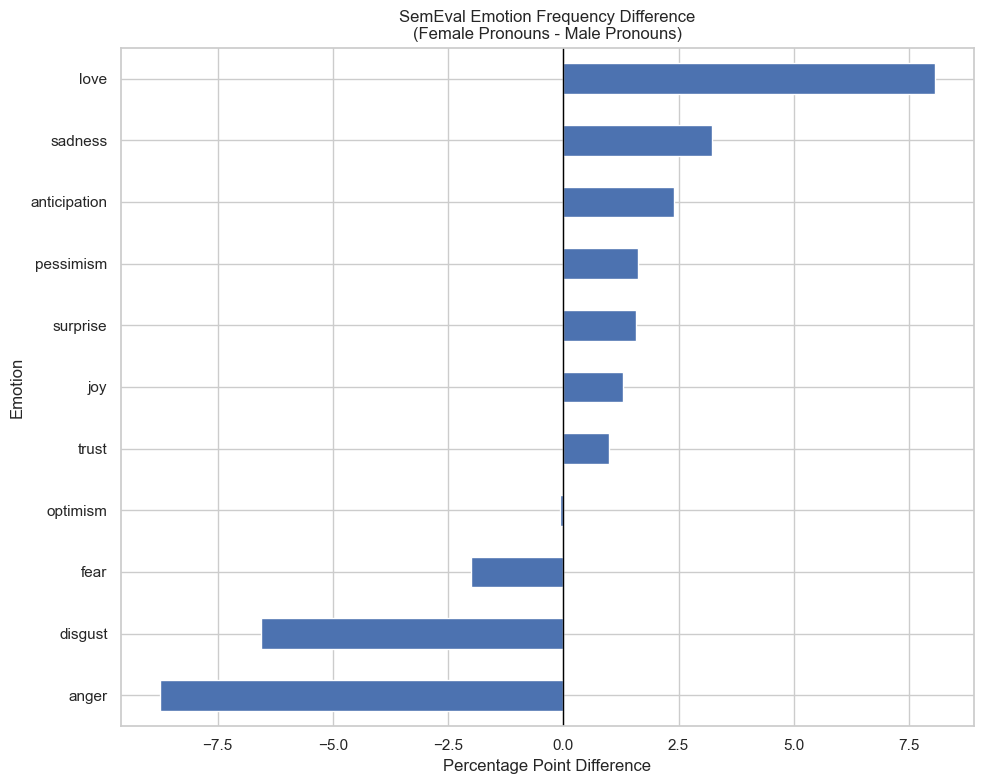

In [87]:
S_comparison["Difference"].sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("SemEval Emotion Frequency Difference\n(Female Pronouns - Male Pronouns)")
plt.xlabel("Percentage Point Difference")
plt.ylabel("Emotion")

plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

In [88]:
summary_rows = []

for emotion in S_emotion_cols:

    emotion_texts = S_train.loc[
        S_train[emotion] == 1,
        "Tweet"
    ]

    all_words = []

    for text in emotion_texts:
        all_words.extend(clean_text(text))

    top_words = [
        word
        for word, count in Counter(all_words).most_common(10)
    ]

    summary_rows.append({
        "Emotion": emotion,
        "Most Common Words": top_words
    })

pd.set_option("display.max_colwidth", None)

S_emotion_word_table = pd.DataFrame(summary_rows)

S_emotion_word_table

,Emotion,Most Common Words
0,anger,"[don, amp, angry, anger, fucking, awful, terrible, got, rage, fuming]"
1,anticipation,"[amp, don, start, think, watch, new, blues, good, make, need]"
2,disgust,"[don, amp, awful, terrible, angry, fucking, got, think, make, horrible]"
3,fear,"[fear, anxiety, nervous, nightmare, don, terrorism, amp, horror, panic, terror]"
4,joy,"[happy, love, amp, good, smile, don, watch, amazing, hilarious, lol]"
5,love,"[love, happy, smile, amp, good, amazing, birthday, laughter, watch, life]"
6,optimism,"[happy, good, don, love, amp, life, smile, make, optimism, today]"
7,pessimism,"[don, sad, depression, life, sadness, lost, amp, think, depressing, today]"
8,sadness,"[sad, don, amp, depression, sadness, lost, today, got, depressing, life]"
9,surprise,"[shocking, amp, watch, did, amazing, hilarious, don, lol, live, didn]"


In [108]:
S_cooccurrence = (
    S_train[S_emotion_cols]
    .T
    .dot(S_train[S_emotion_cols])
)

for emotion in S_emotion_cols:
    S_cooccurrence.loc[emotion, emotion] = 0

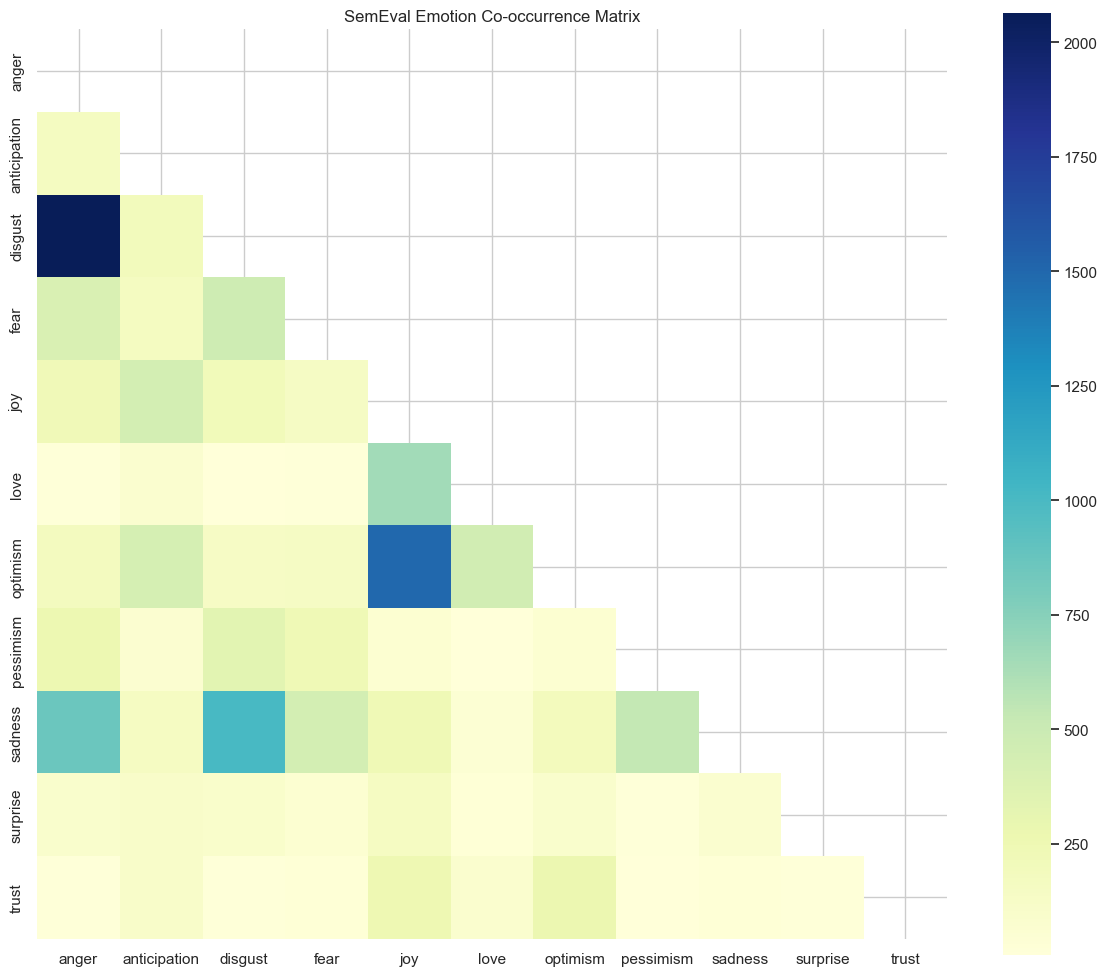

In [112]:
# Hide duplicate half of matrix
mask = np.triu(
    np.ones_like(S_cooccurrence, dtype=bool)
)

plt.figure(figsize=(12,10))

sns.heatmap(
    S_cooccurrence,
    mask=mask,
    cmap="YlGnBu",
    square=True
)

plt.title("SemEval Emotion Co-occurrence Matrix")

plt.tight_layout()
plt.show()

In [106]:
pairs = []

for i, emotion1 in enumerate(S_emotion_cols):
    for emotion2 in S_emotion_cols[i+1:]:

        count = (
            (S_train[emotion1] == 1)
            &
            (S_train[emotion2] == 1)
        ).sum()

        pairs.append([
            emotion1,
            emotion2,
            count
        ])

S_top_pairs = pd.DataFrame(
    pairs,
    columns=[
        "Emotion1",
        "Emotion2",
        "Count"
    ]
)

S_top_pairs = S_top_pairs.sort_values(
    "Count",
    ascending=False
)

S_top_pairs.head(20)

,Emotion1,Emotion2,Count
1,anger,disgust,2064
35,joy,optimism,1495
24,disgust,sadness,1005
7,anger,sadness,865
34,joy,love,655
49,pessimism,sadness,537
19,disgust,fear,477
40,love,optimism,453
12,anticipation,joy,448
31,fear,sadness,445
